In [ ]:
pip install earthengine-api


In [6]:
!pip install earthengine-api geemap --quiet
import ee
import geemap

# Autentifikacija
ee.Authenticate()
ee.Initialize(project='smiling-axiom-459511-f0')  # zamijeni svojim project ID-om


In [7]:
# AOI za grad Osijek (grubo omeđeno pravokutnikom)
aoi = ee.Geometry.Rectangle([18.62, 45.50, 18.74, 45.60])


In [2]:
# Filtriranje Sentinel-2 kolekcije
collection = ee.ImageCollection('COPERNICUS/S2') \
    .filterBounds(aoi) \
    .filterDate('2023-06-01', '2023-08-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)) \
    .median()

# NDVI = (B8 - B4) / (B8 + B4)
ndvi = collection.normalizedDifference(['B8', 'B4']).rename('NDVI')

# Maska za zelene površine (NDVI > 0.3)
green_mask = ndvi.gt(0.3)


NameError: name 'ee' is not defined

In [1]:
# Stapanje RGB + NDVI
# Kombiniraj RGB + NDVI i pretvori sve na float32
stacked = collection.select(['B4', 'B3', 'B2']).addBands(ndvi).toFloat()

task = ee.batch.Export.image.toDrive(
    image=stacked.clip(aoi),
    description='Export_RGB_NDVI',
    folder='EarthEngine',
    fileNamePrefix='osijek_rgb_ndvi',
    scale=10,
    region=aoi,
    maxPixels=1e9
)
task.start()

NameError: name 'collection' is not defined

In [14]:
tasks = ee.batch.Task.list()
for t in tasks:
    print(t.status())


{'state': 'COMPLETED', 'description': 'Export_RGB_NDVI', 'priority': 100, 'creation_timestamp_ms': 1746963198552, 'update_timestamp_ms': 1746963266606, 'start_timestamp_ms': 1746963202394, 'task_type': 'EXPORT_IMAGE', 'destination_uris': ['https://drive.google.com/#folders/1Tcs78PQeWz06JAipZ2nYKxcRFNf5FfEG'], 'attempt': 1, 'batch_eecu_usage_seconds': 123.236083984375, 'id': 'WFLDRSKDBZB7M4LD5N4P3FUM', 'name': 'projects/smiling-axiom-459511-f0/operations/WFLDRSKDBZB7M4LD5N4P3FUM'}
{'state': 'FAILED', 'description': 'Export_RGB_NDVI', 'priority': 100, 'creation_timestamp_ms': 1746962515049, 'update_timestamp_ms': 1746962522040, 'start_timestamp_ms': 1746962518478, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'error_message': 'Exported bands must have compatible data types; found inconsistent types: Float64 and Float32.', 'id': 'YSDW2PWHLLOIR6YTAHGUKPTM', 'name': 'projects/smiling-axiom-459511-f0/operations/YSDW2PWHLLOIR6YTAHGUKPTM'}


In [3]:
!pip install rasterio


   ---------------------------------------- 0.0/25.5 MB ? eta -:--:--
   ---------------------------------------- 0.1/25.5 MB 2.0 MB/s eta 0:00:13
   ---------------------------------------- 0.2/25.5 MB 2.0 MB/s eta 0:00:13
   ---------------------------------------- 0.2/25.5 MB 1.6 MB/s eta 0:00:16
    --------------------------------------- 0.3/25.5 MB 1.8 MB/s eta 0:00:14
    --------------------------------------- 0.5/25.5 MB 1.9 MB/s eta 0:00:13
   - -------------------------------------- 0.6/25.5 MB 2.3 MB/s eta 0:00:11
   - -------------------------------------- 0.8/25.5 MB 2.3 MB/s eta 0:00:11
   - -------------------------------------- 0.9/25.5 MB 2.5 MB/s eta 0:00:10
   - -------------------------------------- 1.1/25.5 MB 2.6 MB/s eta 0:00:10
   - -------------------------------------- 1.2/25.5 MB 2.7 MB/s eta 0:00:09
   -- ------------------------------------- 1.4/25.5 MB 2.9 MB/s eta 0:00:09
   -- ------------------------------------- 1.6/25.5 MB 3.0 MB/s eta 0:00:09
   -- 


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\samue\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt


In [42]:
tif_path='valpovo_rgb_ndvi.tif'

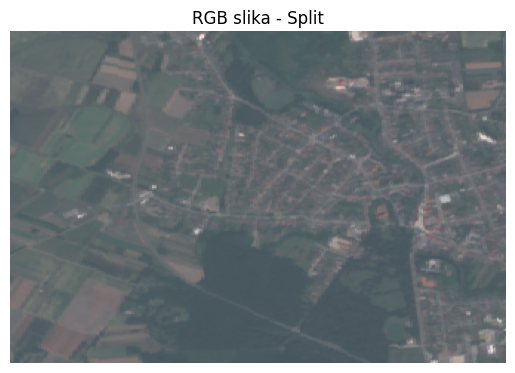

In [44]:
# Učitaj RGB slojeve (Red, Green, Blue)
red = data[0]
green = data[1]
blue = data[2]

# Normaliziraj vrijednosti na [0, 1] za prikaz
rgb = np.stack([red, green, blue], axis=-1)
rgb = rgb.astype(np.float32)
rgb /= rgb.max()  # ili rgb /= 3000.0 ako znaš vrijednosti iz GEE-a

# Prikaz slike
plt.imshow(rgb)
plt.title('RGB slika - Split')
plt.axis('off')
plt.show()


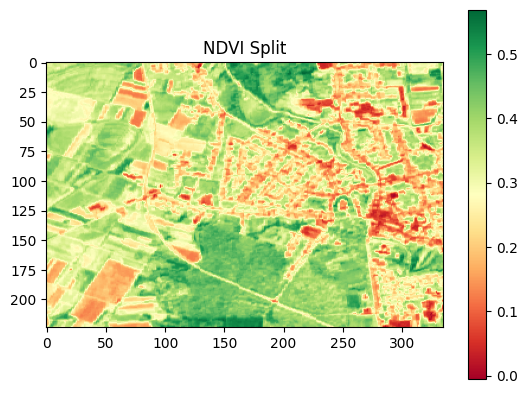

In [43]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open(tif_path) as src:
    data = src.read()         # Oblik: (4, H, W)
    profile = src.profile     # Za metapodatke
    ndvi = data[3].astype(np.float32)

# Prikaži NDVI
plt.imshow(ndvi, cmap='RdYlGn')
plt.title('NDVI Split')
plt.colorbar()
plt.show()


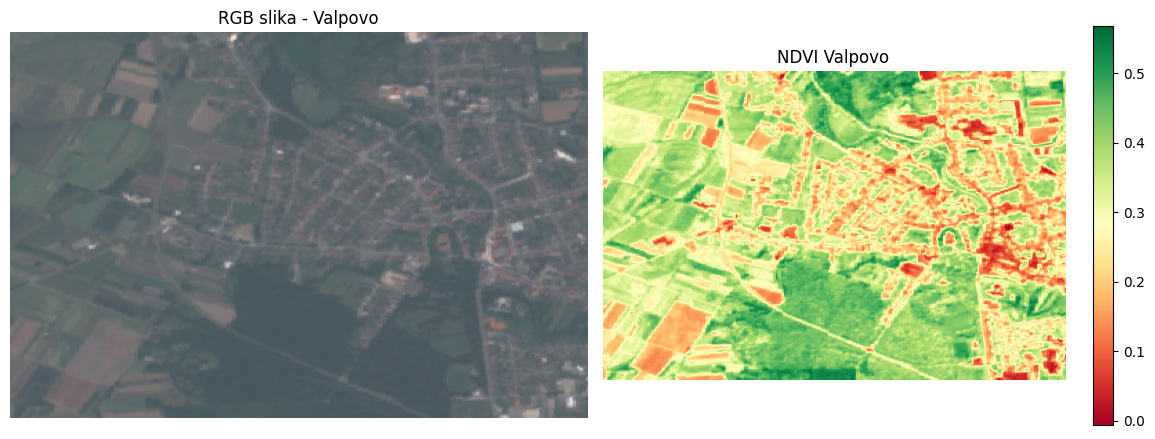

In [45]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Učitaj GeoTIFF
with rasterio.open(tif_path) as src:
    data = src.read()  # Oblik: (4, H, W)

# Izdvoji RGB i NDVI slojeve
red, green, blue = data[0], data[1], data[2]
ndvi = data[3].astype(np.float32)

# Normaliziraj RGB za prikaz
rgb = np.stack([red, green, blue], axis=-1).astype(np.float32)
rgb /= rgb.max()  # Skaliranje u [0, 1]

# Prikaz RGB i NDVI slike jedna pored druge
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title("RGB slika - Valpovo")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ndvi, cmap="RdYlGn")
plt.title("NDVI Valpovo")
plt.colorbar(shrink=0.7)
plt.axis("off")

plt.tight_layout()
plt.show()


In [33]:
print(f"NDVI min: {ndvi.min()}, max: {ndvi.max()}")


NDVI min: -0.15647481381893158, max: 0.5622459053993225


In [48]:
# Pikseli s NDVI > 0.3
green_mask = ndvi > 0.3
green_pixels = np.sum(green_mask)

# Površina piksela Sentinel-2 (10 m rezolucija)
pixel_area_m2 = 10 * 10  # 100 m²

green_area_m2 = green_pixels * pixel_area_m2
total_area_m2 = ndvi.size * pixel_area_m2
green_percent = (green_area_m2 / total_area_m2) * 100

print(f"Zelena površina: {green_area_m2:.2f} m²")
print(f"Udio zelene površine: {green_percent:.2f} %")


Zelena površina: 4615500.00 m²
Udio zelene površine: 61.51 %


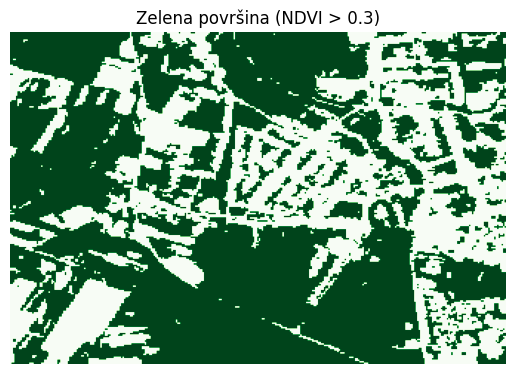

In [49]:
plt.imshow(green_mask, cmap='Greens')
plt.title('Zelena površina (NDVI > 0.3)')
plt.axis('off')
plt.show()
